### Importing Libraries

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

###
### Que 1 : Reading the Data
 For Time Series forecasting we have taken House Property Sales data.
- The data is from 2010 to 2019

In [192]:
data_df = pd.read_csv("raw_sales.csv")

In [193]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datesold      29580 non-null  object
 1   postcode      29580 non-null  int64 
 2   price         29580 non-null  int64 
 3   propertyType  29580 non-null  object
 4   bedrooms      29580 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [194]:
data_df['datesold'] = pd.to_datetime(data_df['datesold'])

In [195]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datesold      29580 non-null  datetime64[ns]
 1   postcode      29580 non-null  int64         
 2   price         29580 non-null  int64         
 3   propertyType  29580 non-null  object        
 4   bedrooms      29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


###
### Que2 : Exploratory Data Analysis
- Checking the basic details and shape of data

In [196]:
# Checking the first few rows of dataframe
data_df.head(6)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3
5,2007-04-04,2905,465000,house,4


In [197]:
# Checking the min and max date
print(data_df['datesold'].min())
print(data_df['datesold'].max())

2007-02-07 00:00:00
2019-07-27 00:00:00


In [198]:
# Checking the Data types and null/not-null counts
print(data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datesold      29580 non-null  datetime64[ns]
 1   postcode      29580 non-null  int64         
 2   price         29580 non-null  int64         
 3   propertyType  29580 non-null  object        
 4   bedrooms      29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB
None


In [199]:
# Checking the unique values of postcode, propertyType and bedrooms
print(f"Unique propert types are : {data_df['propertyType'].unique()}")
print(f"\nUnique bedrooms are : {data_df['bedrooms'].unique()}")
print(f"\nUnique postcodes are : {data_df['postcode'].unique()}")

Unique propert types are : ['house' 'unit']

Unique bedrooms are : [4 3 5 1 2 0]

Unique postcodes are : [2607 2906 2905 2606 2902 2612 2904 2615 2914 2602 2600 2605 2603 2611
 2903 2617 2913 2604 2614 2912 2601 2900 2620 2618 2616 2911 2609]


#####
##### We can see some of the bedrooms are 0 which does not make sense for a housing property. Verifying the count of such houses that are marked with Zero bedrooms, we will remove them from the analysis

In [200]:
# Checking the count of houses with Zero bedrooms
print(f"Count of houses marked with zero bedrooms : {data_df[data_df["bedrooms"] == 0].shape[0]}")

Count of houses marked with zero bedrooms : 30


In [201]:
# Removing these records from the dataset
data_df = data_df[data_df['bedrooms'] != 0]
print(data_df.shape)

print(f"\nUnique bedrooms are : {data_df['bedrooms'].unique()}")

(29550, 5)

Unique bedrooms are : [4 3 5 1 2]


#####
- Checking Basic Summary

In [202]:
# Checking basic Summary statistics
print(data_df.describe())

                            datesold      postcode         price      bedrooms
count                          29550  29550.000000  2.955000e+04  29550.000000
mean   2015-02-21 04:33:22.842639616   2730.323621  6.098047e+05      3.253469
min              2007-02-07 00:00:00   2600.000000  5.650000e+04      1.000000
25%              2013-02-05 00:00:00   2607.000000  4.400000e+05      3.000000
50%              2015-09-30 00:00:00   2615.000000  5.500000e+05      3.000000
75%              2017-07-26 00:00:00   2905.000000  7.050000e+05      4.000000
max              2019-07-27 00:00:00   2914.000000  8.000000e+06      5.000000
std                              NaN    146.729215  2.817045e+05      0.946101


####
- Checking for Missing Values

In [203]:
# Checking for missing values in weather dataframe
missing_values = data_df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64


#####
##### Checking the distribution of the data for outlier detection

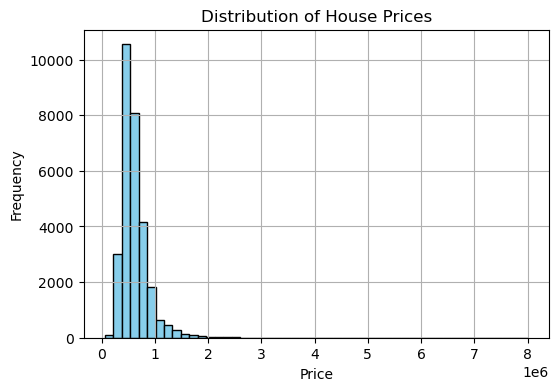

In [204]:
# Histogram for price distribution

plt.figure(figsize=(6, 4))
plt.hist(data_df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


#####
##### Checking the count of houses with prices more than 1 Million and 2 Million Dollars

In [205]:
# House count with prices > $1M and $2M
print(f"Count of houses marked priced more than $1M : {data_df[data_df["price"] > 1000000].shape[0]}")
print(f"\nCount of houses marked priced more than $2M : {data_df[data_df["price"] > 2000000].shape[0]}")

Count of houses marked priced more than $1M : 1836

Count of houses marked priced more than $2M : 120


#####
##### Checking Price distribution based on number of bedrooms

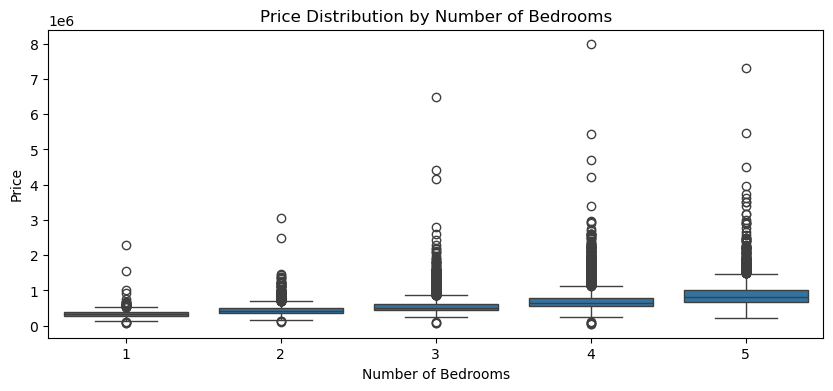

In [206]:
# Boxplot for price distribution based on number of bedrooms

plt.figure(figsize=(10, 4))
# Create the boxplot
sns.boxplot(x='bedrooms', y='price', data=data_df)
# Add titles and labels
plt.title('Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
# Show the plot
plt.show()


#####
##### **Interpretation :**
-  house prices seems to be increasing as the number of bedrooms increases, with less variation between 1 and 2 bedrooms and more variation between higher number of bedrooms.
- We can see few outliers for every category here, it could be because of right skewness that we have observed in above histogram.

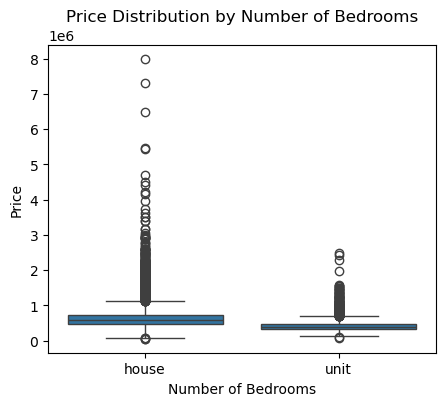

In [207]:
# Checking the price distribution for propertyTypes

plt.figure(figsize=(5, 4))
# Create the boxplot
sns.boxplot(x='propertyType', y='price', data=data_df)
# Add titles and labels
plt.title('Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
# Show the plot
plt.show()

#####
##### **Interpretation :**
- Price distribution of home type 'house' has much wider range than 'unit' home types.
- Unit types has more smaller pricing range with very few outliers.
- House type has much wider range of houses with few extereme outliers above $5M.

#####
##### Checking the percentage of house beyond $5M

In [208]:
# Percentage of properties beyond $5M

total_houses = len(data_df)
houses_above_5_million = len(data_df[data_df['price'] > 5000000])
percentage_above_5_million = (houses_above_5_million / total_houses) * 100

print(f"Count of houses beyond 5 Million Dollars : {houses_above_5_million}")
print(f"Percentage of houses priced above 5 million dollars: {percentage_above_5_million:.2f}%")

Count of houses beyond 5 Million Dollars : 5
Percentage of houses priced above 5 million dollars: 0.02%


In [209]:
# Percentage of properties between 3 and 5 M dollars


houses_between_3_5_million = len(data_df[(data_df['price'] > 3000000) & (data_df['price'] < 5000000)])
percentage_between_3_5_million = (houses_between_3_5_million / total_houses) * 100

print(f"Count of houses between 3 and 5 Million Dollars : {houses_between_3_5_million}")
print(f"Percentage of houses priced between 3 and 5 million dollars: {percentage_between_3_5_million:.2f}%")


Count of houses between 3 and 5 Million Dollars : 15
Percentage of houses priced between 3 and 5 million dollars: 0.05%


In [210]:
# Percentage of properties above 2M dollars


houses_above_2_million = len(data_df[(data_df['price'] > 2000000)])
percentage_above_2_million = (houses_above_2_million / total_houses) * 100

print(f"Count of houses above 2 Million Dollars : {houses_above_2_million}")
print(f"Percentage of houses priced above 2 million dollars: {percentage_above_2_million:.2f}%")


Count of houses above 2 Million Dollars : 120
Percentage of houses priced above 2 million dollars: 0.41%


In [211]:
# Percentage of properties above 1M dollars


houses_above_1_million = len(data_df[(data_df['price'] > 1000000)])
percentage_above_1_million = (houses_above_1_million / total_houses) * 100

print(f"Count of houses above 1 Million Dollars : {houses_above_1_million}")
print(f"Percentage of houses priced above 1 million dollars: {percentage_above_1_million:.2f}%")


Count of houses above 1 Million Dollars : 1836
Percentage of houses priced above 1 million dollars: 6.21%


#####
##### Removing the houses priced beyond $2M. As the % is less than 1%, considering them as outlier before proceeding with forecasting

In [212]:
# Remving the outliers i.e. houses priced more than 3M dollars which is less than 1% of entire data
data_df = data_df[data_df['price'] <= 3000000]
print(data_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29530 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datesold      29530 non-null  datetime64[ns]
 1   postcode      29530 non-null  int64         
 2   price         29530 non-null  int64         
 3   propertyType  29530 non-null  object        
 4   bedrooms      29530 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.4+ MB
None


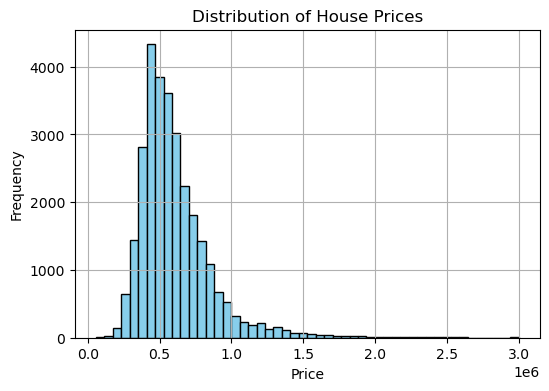

In [213]:
# Checking price distribution again after removal of some entries

# Histogram for price distribution

plt.figure(figsize=(6, 4))
plt.hist(data_df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


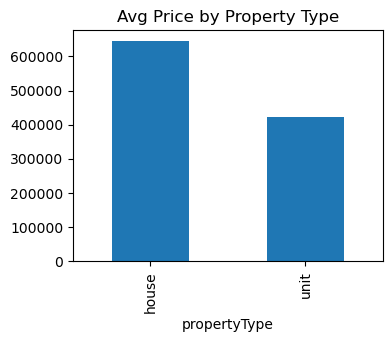

In [93]:
# Average Prices by property type
plt.figure(figsize=(4,3))
data_df.groupby('propertyType')['price'].mean().plot(kind='bar', title="Avg Price by Property Type")
plt.show()

##### **Interpretation :**
- 'House' type homes are much more expensive than 'Unit' type homes.

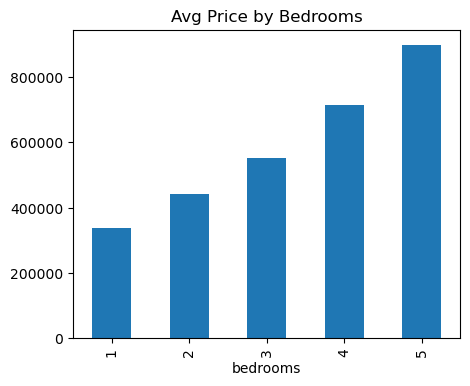

Correlation between price and bedrooms: 0.5150699738163294


In [94]:
# Average Prices by bedrooms
plt.figure(figsize=(5,4))
data_df.groupby('bedrooms')['price'].mean().plot(kind='bar', title="Avg Price by Bedrooms")
plt.show()


# Correlation between price and bedrooms
corr_value = data_df['price'].corr(data_df['bedrooms'])
print("Correlation between price and bedrooms:", corr_value)

#####
##### **Interpretation :**
- Avg prices for house increases as the number of bedrooms increases (slightly positively correlated)

####
- Setting the date column as index

In [95]:
data_df.set_index('datesold', inplace=True)

In [96]:
data_df.head(10)

,postcode,price,propertyType,bedrooms
datesold,,,,
2007-02-07,2607,525000,house,4
2007-02-27,2906,290000,house,3
2007-03-07,2905,328000,house,3
2007-03-09,2905,380000,house,4
2007-03-21,2906,310000,house,3
2007-04-04,2905,465000,house,4
2007-04-24,2607,399000,house,3
2007-04-30,2606,1530000,house,4
2007-05-24,2902,359000,house,3


In [97]:
#  Checking frequency of index
print("Inferred frequency:", data_df.index.inferred_freq)
print("Gaps in index:\n", data_df.index.to_series().diff().value_counts().head())

Inferred frequency: None
Gaps in index:
 datesold
0 days    23889
1 days     4251
2 days      711
3 days      352
4 days      144
Name: count, dtype: int64


#####
##### **Interpretation :**
- Checking to see  if there is any regular frequency observed in Sales like Daily or Monthly.
- Output 'None' here means that there is no fixed pattern to sales. It does not follow a fixed frequency like sales are happenening every day.

####
- Visualise Time Series and Seasonality Analysis

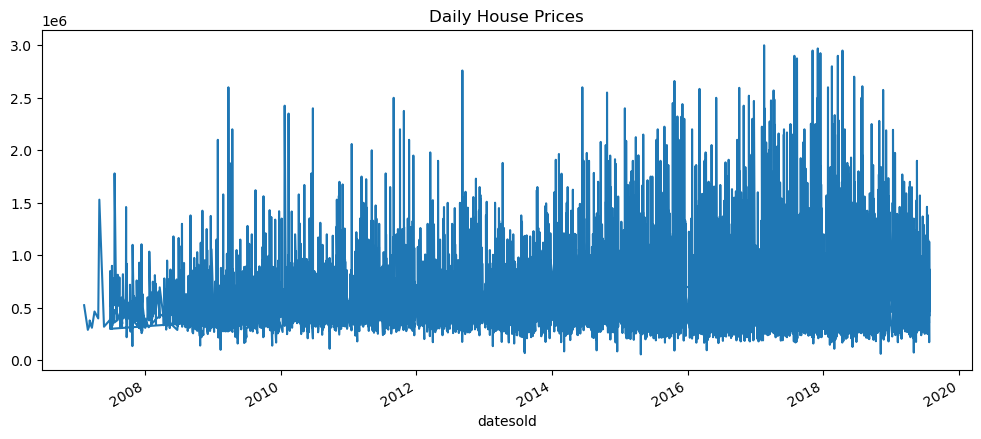

In [98]:
# Plotting daily prices
plt.figure(figsize=(12,5))
data_df['price'].plot(title="Daily House Prices")
plt.show()

#####
##### Interpretation for daily prices over years
- Daily Prices seems to have a lot of variation, too much noise, some extreme outliers on specific days where peak is highest.
- Some days sales is high, some days less sales.
- Do not show any underlying trend or pattern in the data because of raw volatility.

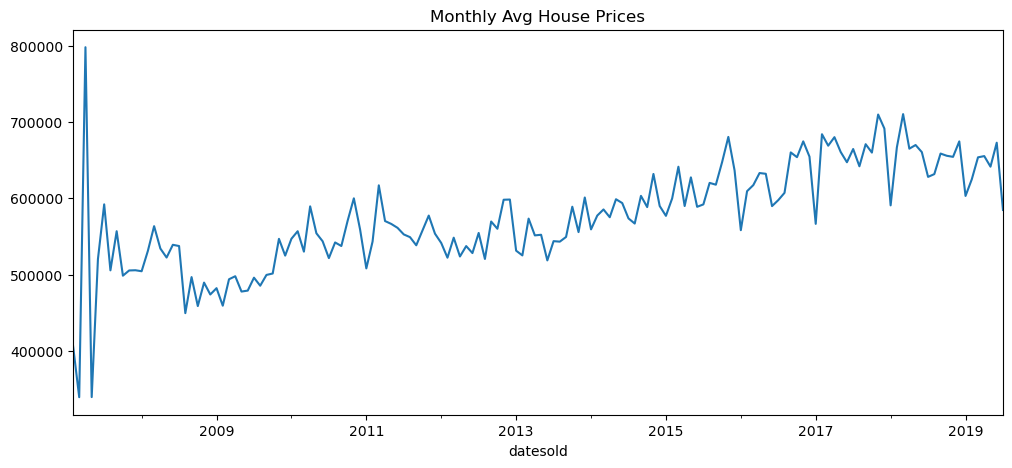

In [99]:
# Plotting monthly average prices (trend smoothing)
plt.figure(figsize=(12,5))
data_df['price'].resample('ME').mean().plot(title="Monthly Avg House Prices")
plt.show()

#####
##### Interpretation for Average Monthly Prices over years
- This data shows an overall increasing trend in prices over years, after some early fluctuations there is a clear upward trend 2012 onwards.
- 2008 to 2010 shows high volatulity with sharp peaks and dips.
- There seems to be some seasonal effects in the pricing.

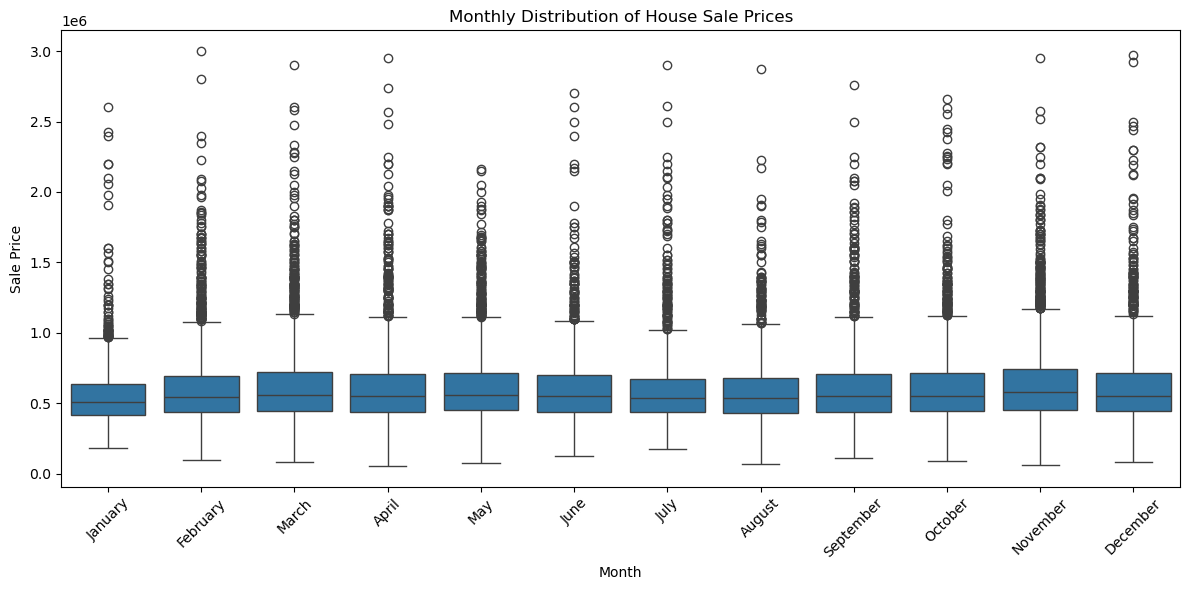

In [100]:

# Monthly average price
monthly_avg_price = data_df['price'].resample('ME').mean()

# Add month name for boxplot
data_df['month'] = data_df.index.month_name()

# Monthly boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='price', data=data_df, order=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
plt.title('Monthly Distribution of House Sale Prices')
plt.xlabel('Month')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#####
##### **Interpretation :**
- Various boxplots shows monthly distribtuion of average sales prices.
- We dont see much variation in house prices on the basis of month. Month does not impact whether the house prices increases or decreases.
- We can few extereme outliers in each month indicating that higher sales does not depend on months either.
- Atleast house prices do not show any seasonal effect.

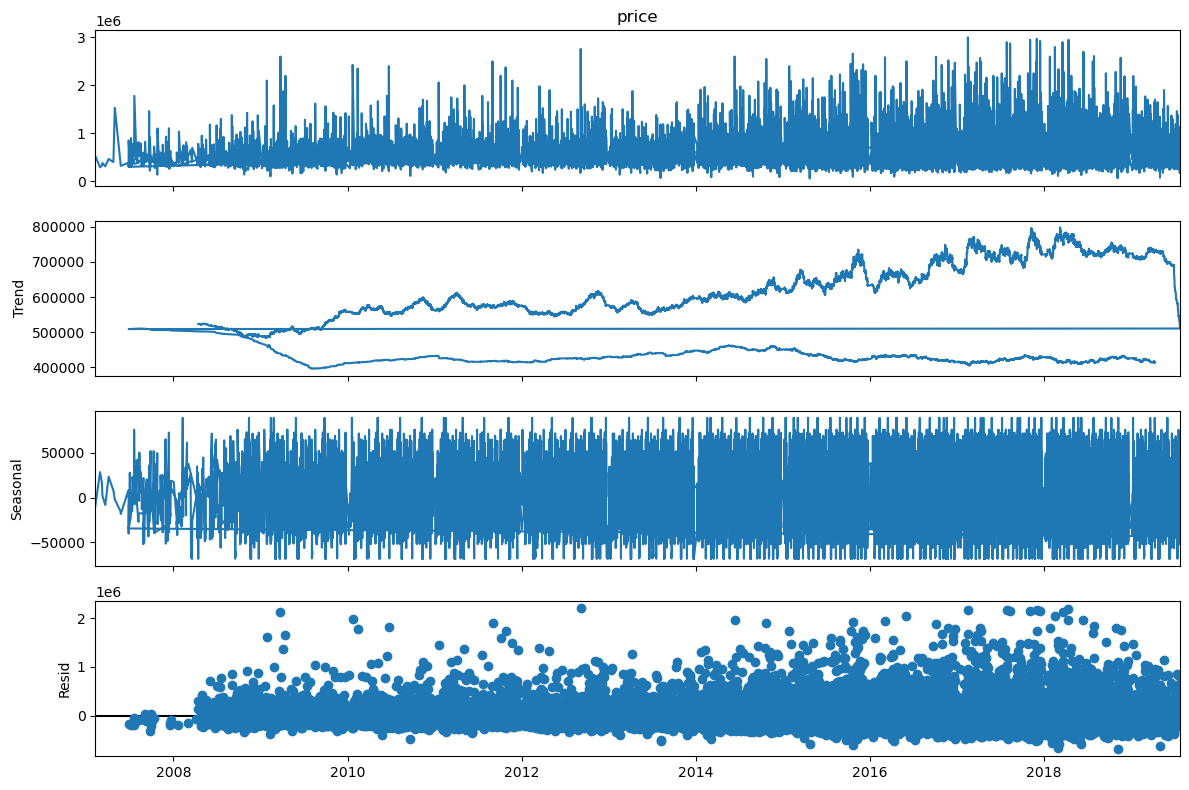

In [101]:
# Decompose into trend/seasonal/residual (yearly seasonality ~ 365 days)
decomposition = seasonal_decompose(data_df['price'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

#####
##### **Interpretation :**
- This is a decomposition graph on raw house prices.
- It shows Original Plot (of Raw house prices over time) = Trend + Seasonal + Residual
- Because of raw level prices, this data is highly volatile and full if noises.
- Generating this for Avg Monthly Seasonlaity below.

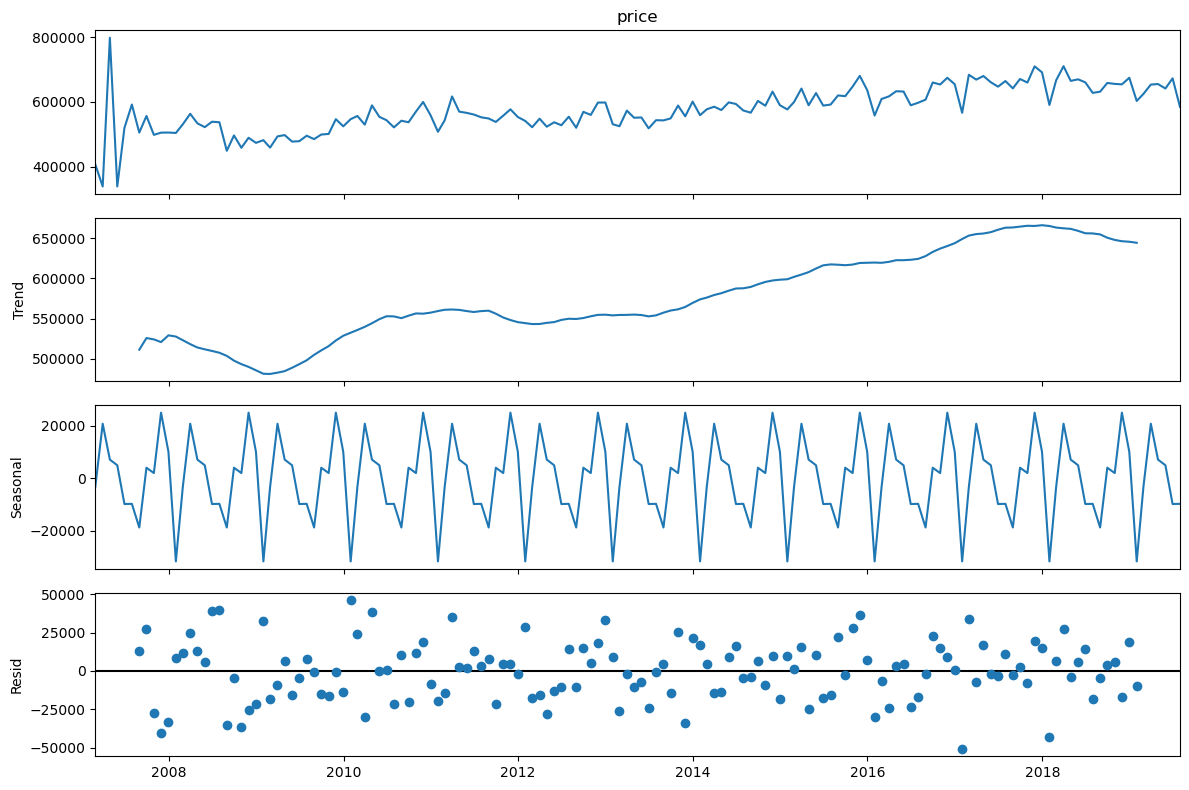

In [102]:
# Seasonal decomposition - Avg Monthly Seasonality
decomposition = seasonal_decompose(monthly_avg_price.dropna(), model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

#####
##### **Interpretation :**
- The top original plot shows the general upward trend for monthly average prices with regular fluctuations.
- The Trend Plot shows a smooth upward flow in house prices after 2009. 
- The seasonal plot follows consistent and clear pattern. Inidcates that house prices may be getting impacted by seasons.
- The Residual graph follows a random scatter pattern around the zero with no major increasing or decreasing variance.

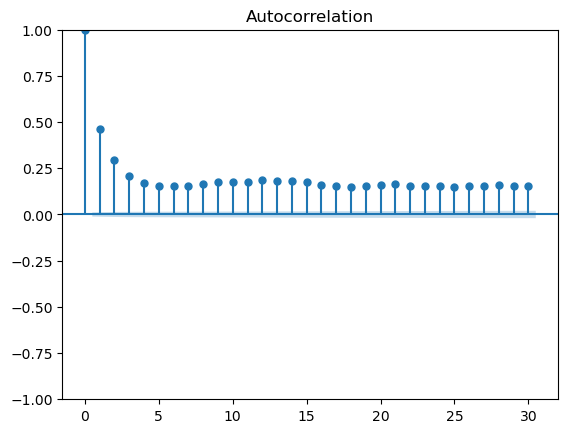

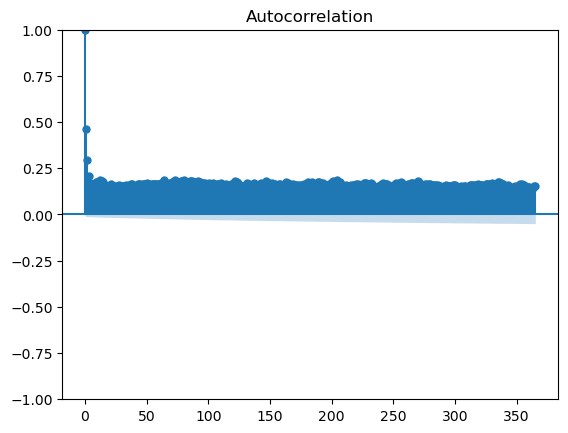

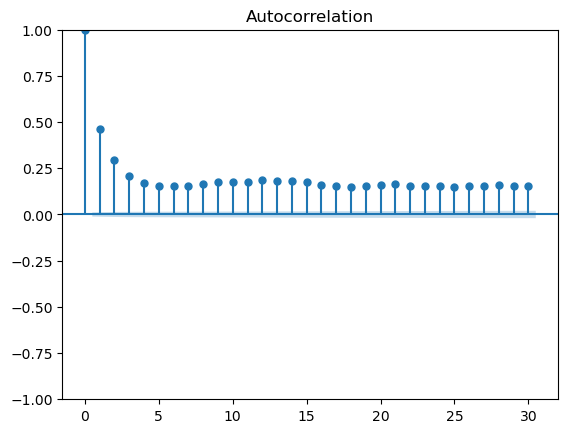

In [103]:
# Checking repeated seasonal patterns

# Correlation of timeseries with itself at different lags

plot_acf(data_df['price'], lags=365)   # yearly correlation
plot_acf(data_df['price'], lags=30)    # monthly correlation

#####
##### **Interpretation :**
- Based on the both yearly and monthly lag plots, we can see that,
    - Correlation is 1 for lag 0 which is expected as its the correlation with itself.
    - correlation at lag 1 decreases and then gradually it decreases for further lags too and then it becomes stable,
    - The decay resembles exponential but does not approach 0, indicating persistence and non-stationarity.
    - As the effect does not reduce to 0, it inidcates that the data has long memory or non-stationarity, meaning past values (even far back) influence present values.

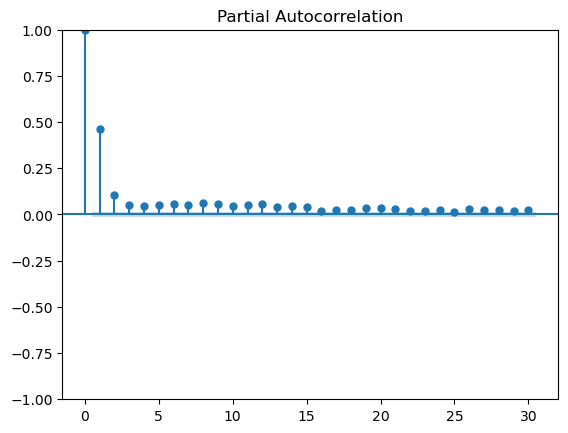

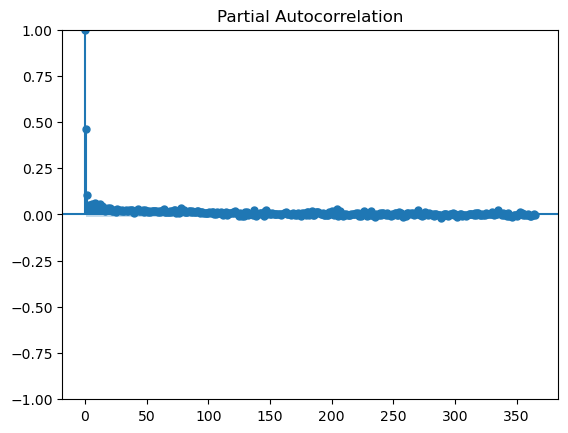

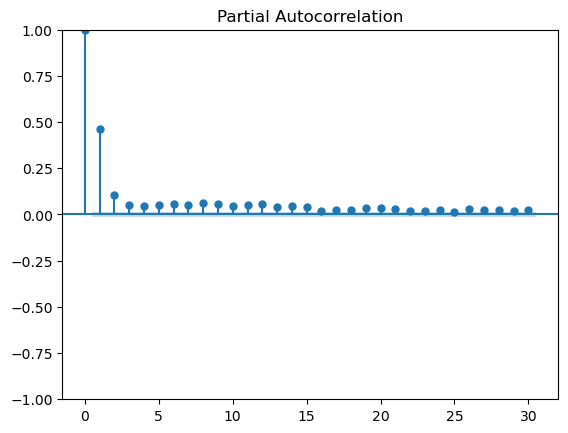

In [104]:
# Plotting Partial Auto Correlation with monthly and yearly lags

plot_pacf(data_df['price'], lags=365)    # yearly correlation
plot_pacf(data_df['price'], lags=30)    # monthly correlation

#####
##### **Interpretation :**
- These PACF plot indicates
    - Strong correlation with lag 1 which make sense as prices dont change very drastically in a day.
    - But the correlation starts lowering significantly from lag 2 and eventually drops to 0 in both monthly and yearly trends.

###
### Ques 3 : Applying Smoothing Methods

- a) Apply Moving Average,
- b) Simple Exponential Smoothing,
- c) Holt’s, and
- d) Holt-Winters.


In [118]:
# Assigning monthly_avg_price created above to a new variable for further usage

# Just sorting the data before copying to ensure data is sorted before test/train split
ts_monthly = monthly_avg_price.sort_index().copy()

# Prepare train/test split
# 80% of sorted data is taken as Training Data (older data) and other 20% (newer data) is taken for test
train_size = int(len(ts_monthly) * 0.8)
train, test = ts_monthly[:train_size], ts_monthly[train_size:]

 ####
 #### a) Applying Moving Average

In [106]:
# Moving Average with fine-tuning

windows = [3, 6, 12]    # Test different windows (monthly, quarterly, yearly)
best_mse = float('inf') # to store the lowest found MSE across all windows
best_window = None      # to store the best window with lowest MSE
best_ma = None          # Moving Average in best window

for window in windows:
    ma_smooth = train.rolling(window=window).mean().dropna()          # taking mean of rolling average in a window
    mse = ((ma_smooth - train[window-1:]) ** 2).mean()                # MSE on train (aligned)
    if mse < best_mse:
        best_mse = mse
        best_window = window
        best_ma = ma_smooth

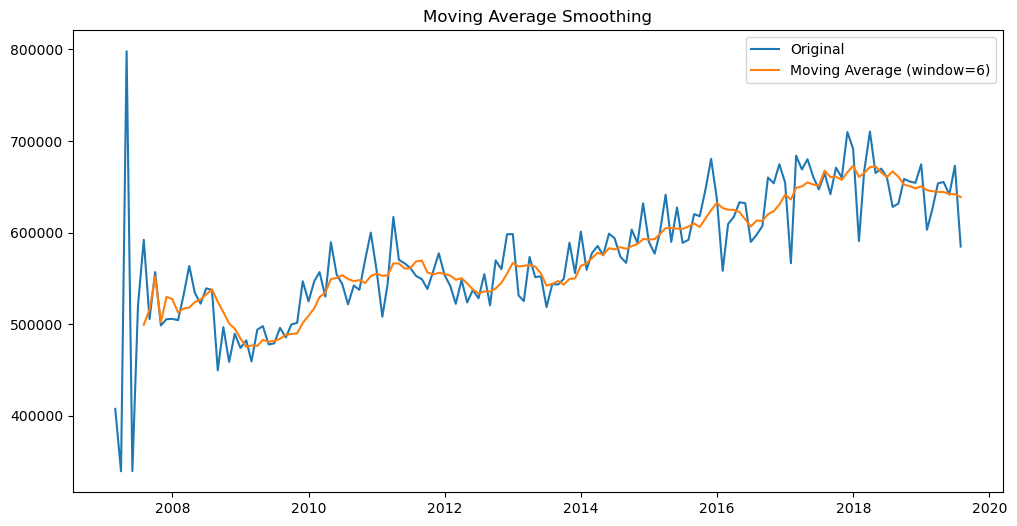

Best MA window: 6, Train MSE: 648899421.1849988


In [107]:

# Apply best window with lowest MSE to calculate the moving average on full training dataset
ma_full = ts_monthly.rolling(window=best_window).mean()


# Plotting for visualisation
plt.figure(figsize=(12, 6))
plt.plot(ts_monthly, label='Original')
plt.plot(ma_full, label=f'Moving Average (window={best_window})')
plt.title('Moving Average Smoothing')
plt.legend()
plt.show()

print(f'Best MA window: {best_window}, Train MSE: {best_mse}')

####
#### **Interpretation :**
- This plot shows how the moving average smooths out the noise in the original series and makes underlying patterns more apparent based on the best window size identified in previous step.

####
#### b) Simple Exponential Smoothing (SES)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


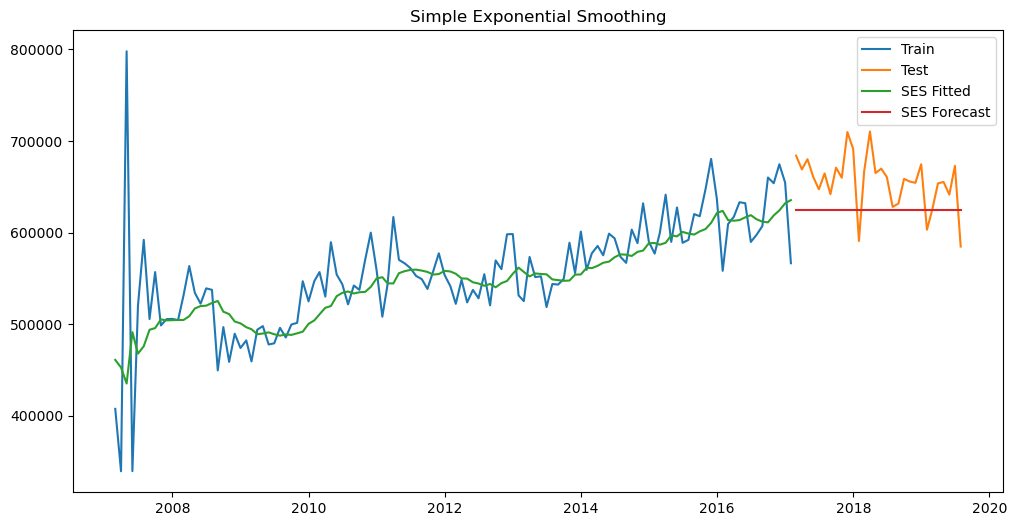

SES Optimized Alpha: 0.155, Test MSE: 1809811557.9405425


In [113]:
#### --- Simple Exponential Smoothing (SES) --- ####

# -----------------------
# Weighted average of all past observations with more weight to recent data points and less weight to older data points.
# The rate at which weight decreases defined by alpha
# -----------------------


# importing relevant library
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fitting Exponential Smoothening Model for optimizer to automatically find the best solution
ses_model = ExponentialSmoothing(train).fit(optimized=True)                                   # initialised the model instance to fit on training with with auto optimisation of smootheningparameter alpha.
ses_fitted = ses_model.fittedvalues                                                           # Get the values fitted by the model
ses_forecast = ses_model.forecast(len(test))                                                  # Forecast the values for steps as equal to test data
ses_mse = ((ses_forecast - test) ** 2).mean()                                                 # getting MSE

# Plotting for visualisation
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(ses_fitted, label='SES Fitted')
plt.plot(ses_forecast, label='SES Forecast')
plt.title('Simple Exponential Smoothing')
plt.legend()
plt.show()

print(f'SES Optimized Alpha: {ses_model.params["smoothing_level"]:.3f}, Test MSE: {ses_mse}')

####
#### **Interpretation :**
- Looking at this plot
    - SES fits values on train data foloowing the general trend of training data.
    - SES forecast on Test data seems to be straight line missing the fluctuations in the actual data
    - A very large MSE indicates that there is very large difference between forecasted and actual values.

####
#### c) Holt’s Linear Trend

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


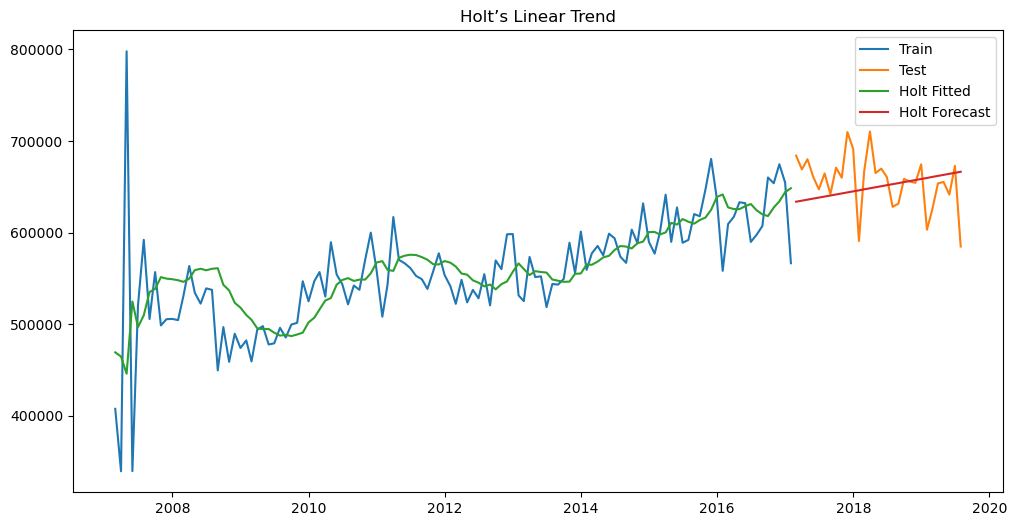

Holt Alpha: 0.194, Beta: 0.075, Test MSE: 1193340078.2195795


In [112]:
#### --- Holt’s Linear Trend ---- #

# ---------------------
# Similar to SES but along with exponential weights to data points, Holt's Linear Trend assumes data to have an increasing or decreasing linear trend.
# ALong with parameter alpha for weights, it takes on another parameter beta to adjust the rate of change in the slope of the series.
# ---------------------


holt_model = ExponentialSmoothing(train, trend='add').fit(optimized=True)   # fitting the model on train data with auto Optimization for  alpha, beta
holt_fitted = holt_model.fittedvalues                                       # Fitted values on training data
holt_forecast = holt_model.forecast(len(test))                              # Forecast on test durations
holt_mse = ((holt_forecast - test) ** 2).mean()                             # MSE


# Plotting visualisation
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(holt_fitted, label='Holt Fitted')
plt.plot(holt_forecast, label='Holt Forecast')
plt.title('Holt’s Linear Trend')
plt.legend()
plt.show()

print(f'Holt Alpha: {holt_model.params["smoothing_level"]:.3f}, Beta: {holt_model.params["smoothing_trend"]:.3f}, Test MSE: {holt_mse}')

#####
##### **Interpretation :**
- The fitted values are able to capture the general upward and downward trend of the actual training data.
- The forecasted values does capture the slight upward trend but does nt capture the true nature of actual test data.
- Around 2019 forecasted values are higher than actual test values.
- There still seems to be deviation in the forecasted values as captured by large MSE as well.

####
#### d) Holt-Winters Seasonal

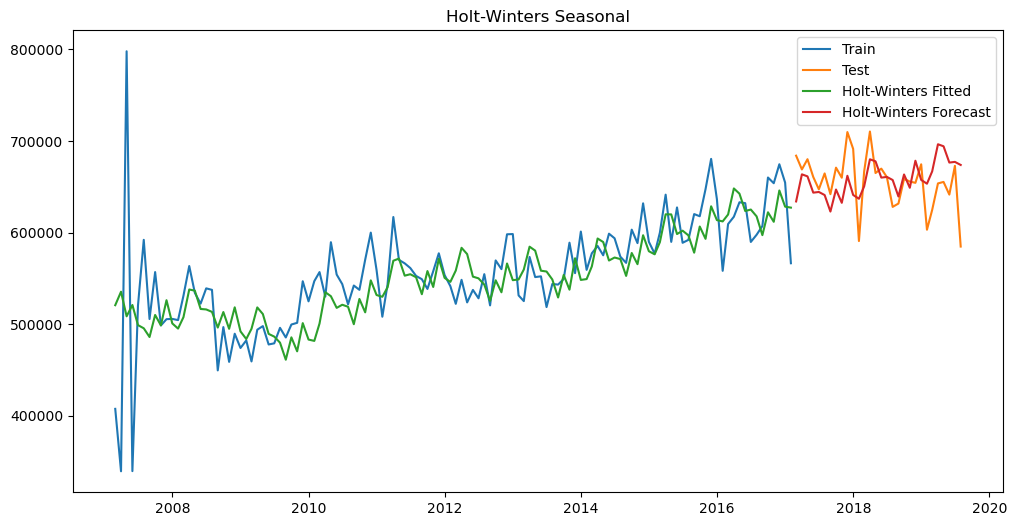

HW Alpha: 0.111, Beta: 0.025, Gamma: 0.000, Test MSE: 1083091693.6261747


In [214]:
##### ---- Holt-Winters Seasonal ---- ###

import warnings
warnings.filterwarnings('ignore')

# ---------------------
# Similar to Holt's Linear Trend but along with alpha and beta, it captures one more parameter Gamma i.e. the seasonality in the data
# Seasonality can either be Additive or Multiplicative
# ---------------------

# Model Fit
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)  # Optimize alpha, beta, gamma
hw_fitted = hw_model.fittedvalues
hw_forecast = hw_model.forecast(len(test))
hw_mse = ((hw_forecast - test) ** 2).mean()


# Plotting Visualisation
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(hw_fitted, label='Holt-Winters Fitted')
plt.plot(hw_forecast, label='Holt-Winters Forecast')
plt.title('Holt-Winters Seasonal')
plt.legend()
plt.show()

print(f'HW Alpha: {hw_model.params["smoothing_level"]:.3f}, Beta: {hw_model.params["smoothing_trend"]:.3f}, Gamma: {hw_model.params["smoothing_seasonal"]:.3f}, Test MSE: {hw_mse}')

#####
##### **Interpretation :**
- Fitted values capture the trend as well as the seasonality very well.
- Forecasted values seems to have captured the trend and sesonality very well as compared to ealier techniques.

####
### ARIMA and SARIMA Models



#### Applying ARIMA (non-seasonal) 
- Fine-tune parameters via grid search minimizing AIC

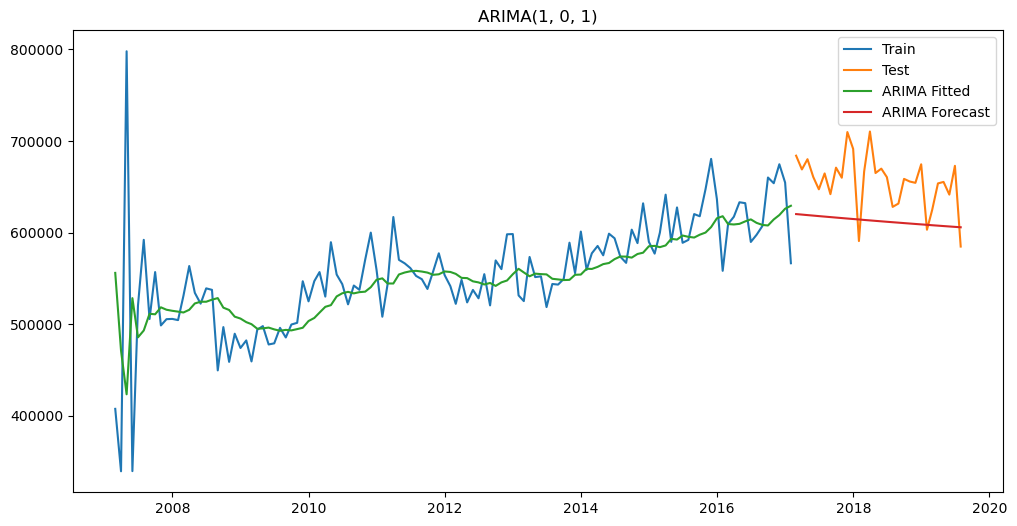

Best ARIMA params: (1, 0, 1), AIC: 2939.555666633608, Test MSE: 2631326890.47094


In [215]:
# --------- ARIMA with grid search fine-tuning -------- #

# -----------------------
# The ARIMA model is specified by three parameters: (p, d, q).
# p: The order of the autoregressive (AR) part i.e. number of lagged observations to consider
# d: The degree of differencing (I) i.e. how many times the series needs to be differenced to become stationary
# q: The order of the moving average (MA) part i.e. number of lagged forecast errors to include
# ------------------------

from statsmodels.tsa.arima.model import ARIMA
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# defining parameters
p = range(0, 3)
d = range(0, 2)
q = range(0, 3)
pdq = list(product(p, d, q))

best_aic = float('inf')
best_params = None
best_arima = None


# Model Fit
for param in pdq:
    try:
        model = ARIMA(train, order=param)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_params = param
            best_arima = results
    except:
        continue

arima_forecast = best_arima.forecast(len(test))
arima_mse = ((arima_forecast - test) ** 2).mean()


# Plotting visualisation
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(best_arima.fittedvalues, label='ARIMA Fitted')
plt.plot(arima_forecast, label='ARIMA Forecast')
plt.title(f'ARIMA{best_params}')
plt.legend()
plt.show()

print(f'Best ARIMA params: {best_params}, AIC: {best_aic}, Test MSE: {arima_mse}')

#####
##### **Interpretation :**
- The best model with least MSE is built using p=1, d=0 and q=1 i.e. one past value, no differencing and 1 past forecast error.
- The forecasted values shows a general downward trend in the values but so different from the actual test data.

####
#### **SARIMA**: Seasonal ARIMA extending ARIMA for seasonality

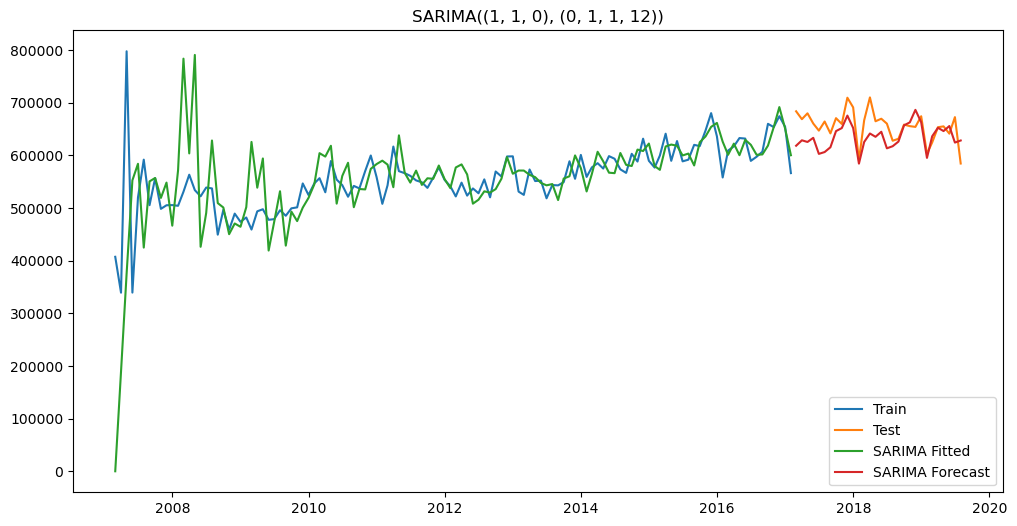

Best SARIMA params: ((1, 1, 0), (0, 1, 1, 12)), AIC: 2614.3150147038905, Test MSE: 1173525413.864272


In [128]:
# ------------- SARIMA with grid search fine-tuning --------------
# -- its an extension of ARIMA and speicifcally designed to capture seasonality too


from statsmodels.tsa.statespace.sarimax import SARIMAX

# Non-seasonal and seasonal params (smaller range for computation)
pdq = list(product(range(0, 2), range(0, 2), range(0, 2)))  # p,d,q            # Normal ARIMA parameters
PDQm = list(product(range(0, 2), range(0, 2), range(0, 2)))  # P,D,Q (m=12)    # parameters for seasonality

best_aic = float('inf')
best_params = None
best_sarima = None


# Model Fit
for param in pdq:
    for s_param in PDQm:
        try:
            model = SARIMAX(train, order=param, seasonal_order=s_param + (12,))
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = (param, s_param + (12,))
                best_sarima = results
        except:
            continue

sarima_forecast = best_sarima.forecast(len(test))
sarima_mse = ((sarima_forecast - test) ** 2).mean()


# Plotting Visualisation
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(best_sarima.fittedvalues, label='SARIMA Fitted')
plt.plot(sarima_forecast, label='SARIMA Forecast')
plt.title(f'SARIMA{best_params}')
plt.legend()
plt.show()

print(f'Best SARIMA params: {best_params}, AIC: {best_aic}, Test MSE: {sarima_mse}')

#####
##### **Interpretation :**
- Fitted values captures the trend and seasonality well but it over fits the value for some time periods.
- But the Forecasted values seems to have captured both trend and seasonality well.
- MSE is also reduced drastically as compared to ARIMA results

####
### Prophet Model
- Applying Facebook's Prophet for forecasting with automatic seasonality.
- Fine-tune changepoint_prior_scale and yearly_seasonality.

In [131]:
#pip install prophet

21:13:02 - cmdstanpy - INFO - Chain [1] start processing
21:13:03 - cmdstanpy - INFO - Chain [1] done processing
21:13:03 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:13:03 - cmdstanpy - INFO - Chain [1] start processing
21:13:04 - cmdstanpy - INFO - Chain [1] done processing
21:13:04 - cmdstanpy - INFO - Chain [1] start processing
21:13:04 - cmdstanpy - INFO - Chain [1] done processing
21:13:04 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:13:04 - cmdstanpy - INFO - Chain [1] start processing
21:13:04 - cmdstanpy - INFO - Chain [1] done processing
21:13:04 - cmdstanpy - INFO - Chain [1] start processing
21:13:04 - cmdstanpy - INFO - Chain [1] done processing
21:13:04 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abn

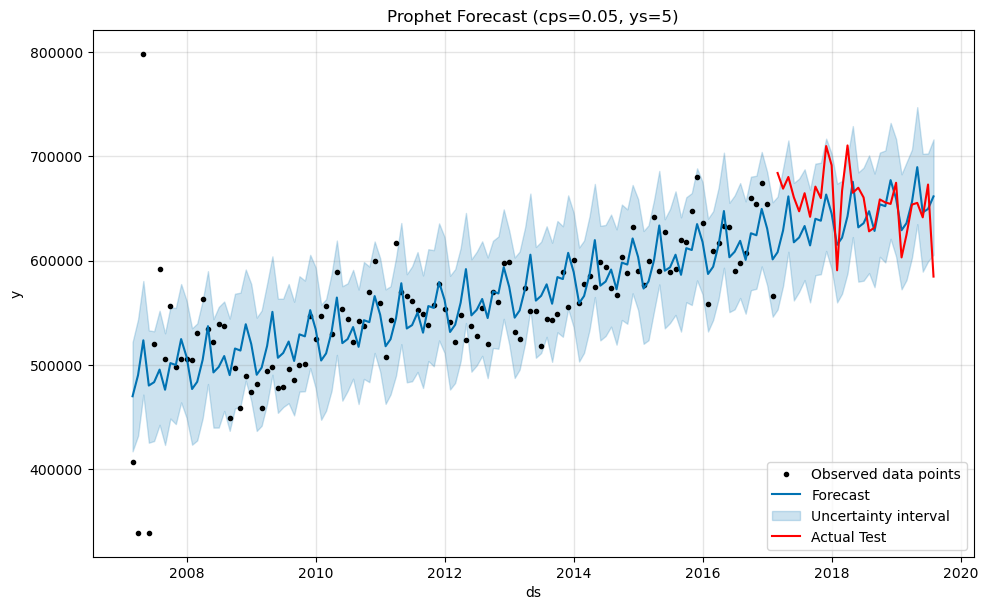

Best Prophet params: cps=0.05, ys=5, Test MSE: 1221189723.5774186


In [130]:
# Prophet with fine-tuning
from prophet import Prophet
import pandas as pd  # For DataFrame
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for Prophet (ds: datetime, y: value)
prophet_train = pd.DataFrame({'ds': train.index, 'y': train.values})
prophet_test = pd.DataFrame({'ds': test.index, 'y': test.values})

# Grid for fine-tuning
params_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.5],
    'yearly_seasonality': [5, 10, 20]  # Strength of yearly seasonality
}

best_mse = float('inf')
best_params = None
best_prophet = None
best_forecast = None

for cps in params_grid['changepoint_prior_scale']:
    for ys in params_grid['yearly_seasonality']:
        model = Prophet(
            changepoint_prior_scale=cps,
            yearly_seasonality=ys,
            weekly_seasonality=False,  # No weekly in monthly data
            daily_seasonality=False
        )
        model.fit(prophet_train)
        future = model.make_future_dataframe(periods=len(test), freq='M')
        forecast = model.predict(future)
        forecast_test = forecast['yhat'][-len(test):]
        mse = ((forecast_test - test.values) ** 2).mean()
        if mse < best_mse:
            best_mse = mse
            best_params = (cps, ys)
            best_prophet = model
            best_forecast = forecast

# Plot
fig = best_prophet.plot(best_forecast)
plt.plot(test.index, test.values, label='Actual Test', color='red')
plt.title(f'Prophet Forecast (cps={best_params[0]}, ys={best_params[1]})')
plt.legend()
plt.show()

print(f'Best Prophet params: cps={best_params[0]}, ys={best_params[1]}, Test MSE: {best_mse}')

#####
##### **Interpretation :**
- The blue forecasted line goes through the black observed data points well following the trend but seems to have missed some observations
- For the actual Test dataset, it seems to have followed a good pattern in terms of trend as well as in seasonality.

####
### LSTM Model (using PyTorch)
- Apply LSTM neural network for sequence forecasting.
- Fine-tune hidden_size, num_layers, lr, epochs.

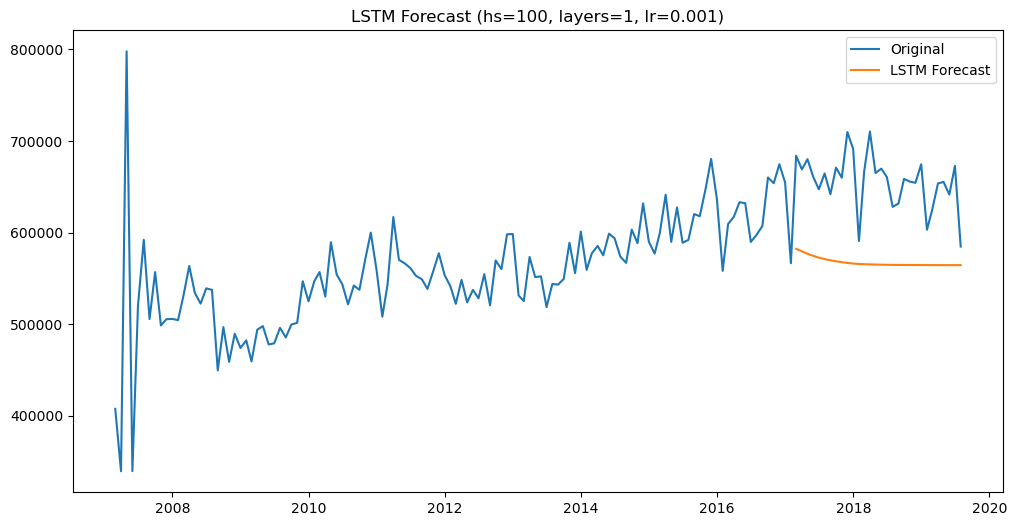

Best LSTM params: {'hidden_size': 100, 'num_layers': 1, 'lr': 0.001, 'epochs': 100}, Test MSE: 8613206878.620684


In [132]:
#LSTM with fine-tuning
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler

# Scale data
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts_monthly.values.reshape(-1, 1))
train_scaled = ts_scaled[:train_size]
test_scaled = ts_scaled[train_size:]

# Create sequences (window=12 for yearly lookback)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 12
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# To tensors
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

# LSTM Model
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Grid for fine-tuning
params_grid = [
    {'hidden_size': 50, 'num_layers': 1, 'lr': 0.001, 'epochs': 100},
    {'hidden_size': 100, 'num_layers': 1, 'lr': 0.001, 'epochs': 100},
    {'hidden_size': 50, 'num_layers': 2, 'lr': 0.01, 'epochs': 50}
]

best_mse = float('inf')
best_params = None
best_lstm_forecast = None

for params in params_grid:
    model = LSTM(hidden_size=params['hidden_size'], num_layers=params['num_layers'])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])

    # Train
    for epoch in range(params['epochs']):
        outputs = model(X_train)
        optimizer.zero_grad()
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

    # Forecast (recursive for full test)
    test_inputs = train_scaled[-seq_length:].tolist()
    lstm_forecast = []
    for _ in range(len(test)):
        seq = torch.FloatTensor(test_inputs[-seq_length:]).view(1, seq_length, 1)
        with torch.no_grad():
            next_val = model(seq)
        lstm_forecast.append(next_val.item())
        test_inputs.append([next_val.item()])

    # Inverse scale
    lstm_forecast = scaler.inverse_transform(np.array(lstm_forecast).reshape(-1, 1)).flatten()
    mse = ((lstm_forecast - test.values) ** 2).mean()  # Align lengths if needed
    if mse < best_mse:
        best_mse = mse
        best_params = params
        best_lstm_forecast = lstm_forecast

# Plot
plt.figure(figsize=(12, 6))
plt.plot(ts_monthly.index, ts_monthly.values, label='Original')
plt.plot(test.index, best_lstm_forecast, label='LSTM Forecast')
plt.title(f'LSTM Forecast (hs={best_params["hidden_size"]}, layers={best_params["num_layers"]}, lr={best_params["lr"]})')
plt.legend()
plt.show()

print(f'Best LSTM params: {best_params}, Test MSE: {best_mse}')

#####
##### **Interpretation :**
- Does not seem to capture the trend for Test Data at all.

###
### Que 4 : Forecast Accuracy Evaluation and Comparison

- Evaluate all models (MA, SES, Holt’s, Holt-Winters, ARIMA, SARIMA, Prophet, LSTM) using **MAE, RMSE, MAPE, and MASE**.
- Compare in a table and visualize forecasts/errors

In [133]:
# Define metrics and evaluate
from sklearn.metrics import mean_absolute_error

In [142]:
# Define MASE function : Mean Absolute Error : Average of the absolute difference between actual and forecasted values : (mean(|actual[t] - actual[t-1]|))

# Interpretation of MASE:
# MASE < 1: Your forecast is, on average, better than the naive forecast. This is generally a good sign.
# MASE = 1: Your forecast is, on average, about as good as the naive forecast.
# MASE > 1: Your forecast is, on average, worse than the naive forecast. This suggests that a simple naive forecast would have been better than your model's forecast.

def mase(actual, forecast, naive_error=None):
    actual, forecast = np.array(actual), np.array(forecast)
    if naive_error is None:
        naive_error = np.mean(np.abs(actual[1:] - actual[:-1]))  # Naive forecast error
    return np.mean(np.abs(actual - forecast)) / naive_error

In [144]:
# Collect forecasts (ensure alignment with test set)

# Creating a dictionary to store all forecast results in one place
forecasts = {
    'Moving Average': ma_full[-len(test):].dropna(),
    'SES': ses_forecast,
    'Holt': holt_forecast,
    'Holt-Winters': hw_forecast,
    'ARIMA': arima_forecast,
    'SARIMA': sarima_forecast,
    'Prophet': best_forecast['yhat'][-len(test):].values,
    'LSTM': best_lstm_forecast
}

In [145]:
# Adjust test set for MA (due to window lag)
# aligning the actual test set with forecasted test results to ensure correct comparison is done

test_aligned = test.iloc[-len(forecasts['Moving Average']):] if len(forecasts['Moving Average']) < len(test) else test

In [146]:
# Compute metrics
results = []
for name, forecast in forecasts.items():
    # Align lengths
    test_vals = test_aligned.values if name == 'Moving Average' else test.values[:len(forecast)]
    forecast = forecast[:len(test_vals)]  # Ensure same length

    mae = mean_absolute_error(test_vals, forecast)
    rmse = np.sqrt(((test_vals - forecast) ** 2).mean())
    mape = np.mean(np.abs((test_vals - forecast) / test_vals)) * 100
    mase_val = mase(test_vals, forecast)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'MASE': mase_val
    })

In [147]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')  # Sort by RMSE for ranking
print("\nForecast Accuracy Metrics:")
print(results_df)


Forecast Accuracy Metrics:
            Model           MAE          RMSE   MAPE (%)      MASE
0  Moving Average  19630.117111  26419.153539   3.046081  0.684514
3    Holt-Winters  26463.808872  32910.358455   4.094497  0.922809
5          SARIMA  28089.458820  34256.757200   4.227834  0.979496
2            Holt  27256.825208  34544.754714   4.186628  0.950462
6         Prophet  28819.468635  34945.525087   4.378157  1.004952
1             SES  37646.401632  42541.880047   5.654853  1.312753
4           ARIMA  60275.263851  65642.470809   9.029584  2.101835
7            LSTM  88521.763167  92807.364356  13.329175  3.086807


#####
##### **Interpretation :**
- Based on above results
    - Moving Average, despite being the simplest, seems to be performing the best with least MASE and other metrics.
    - Holt's Winter, SARIMA, Holt seems to be performing similar on all metrics
    - Rest of the other models are worse than other models with MASE > 1

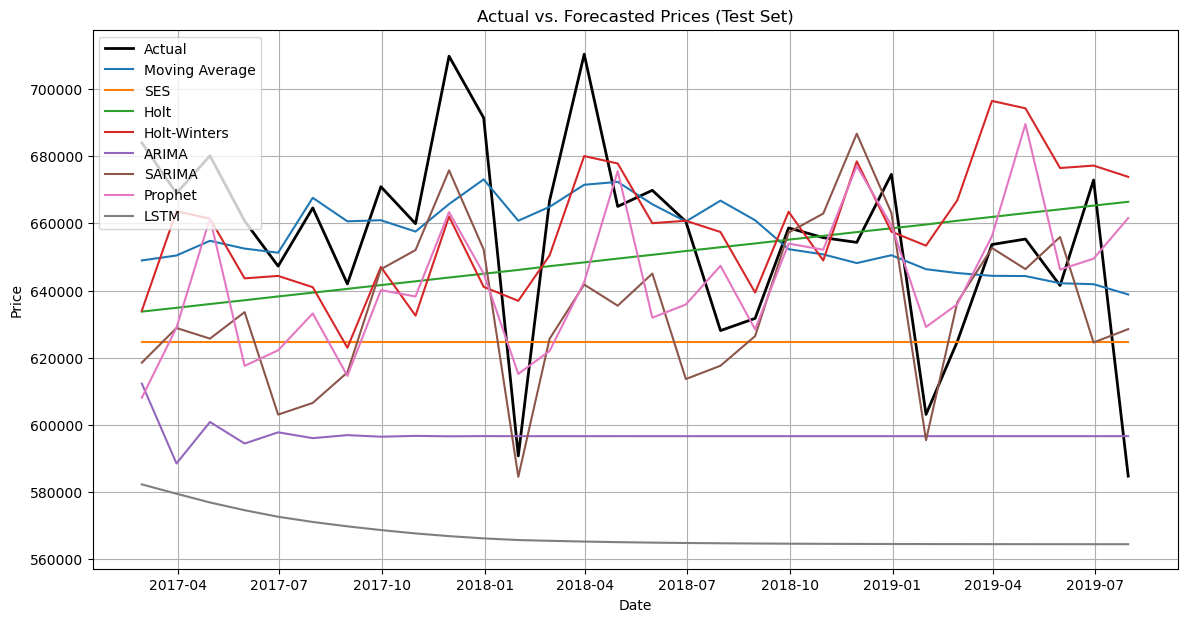

In [139]:
# Code cell: Plot actual vs. forecasts
plt.figure(figsize=(14, 7))
plt.plot(test.index, test.values, label='Actual', color='black', linewidth=2)
for name, forecast in forecasts.items():
    test_idx = test_aligned.index if name == 'Moving Average' else test.index[:len(forecast)]
    plt.plot(test_idx, forecast, label=name)
plt.title('Actual vs. Forecasted Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

#####
##### **Interpretation :**
- Based on above plot
    - we can see that even though Moving Average had best MASE but it does not capture the seasonality very well,though it follows the general trend.
    - The Holt's Winter and SARIMA model seems to be capturing a bit of seasonality as well, not very great though

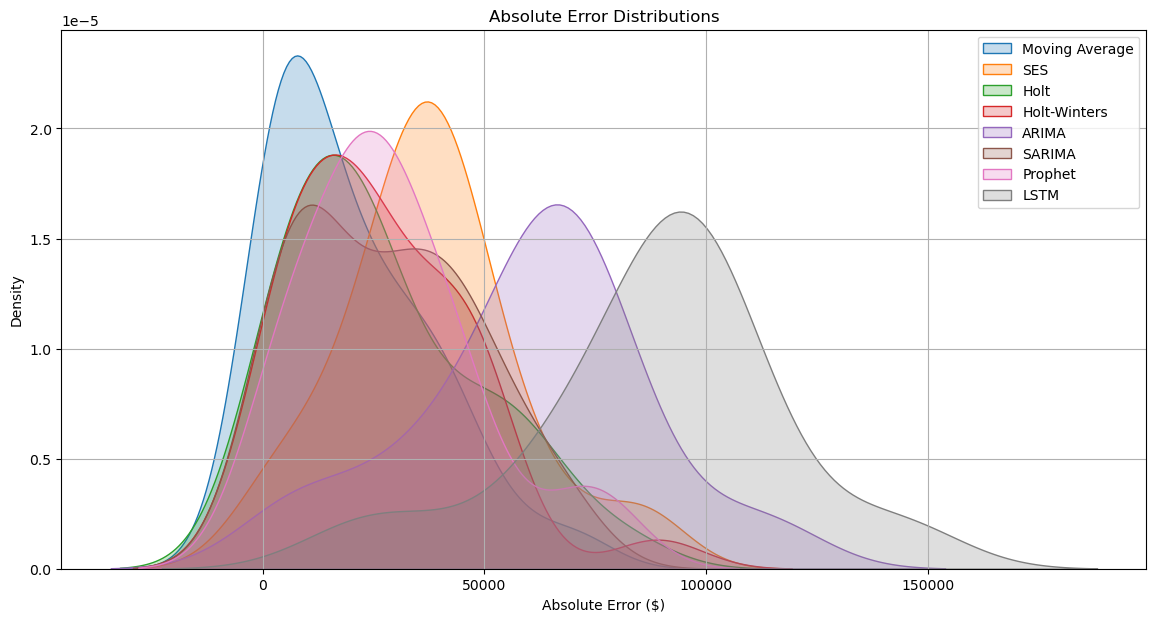

In [140]:
# Plot absolute error distributions
plt.figure(figsize=(14, 7))
for name, forecast in forecasts.items():
    test_vals = test_aligned.values if name == 'Moving Average' else test.values[:len(forecast)]
    errors = np.abs(test_vals - forecast)
    sns.kdeplot(errors, label=name, shade=True)
plt.title('Absolute Error Distributions')
plt.xlabel('Absolute Error ($)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

#####
##### **Insights :**
- This plot allows for a visual comparison of the error characteristics of each model:
    - Location of the peak: A distribution with a peak closer to zero on the x-axis indicates that the model frequently has small absolute errors.
    - Spread (width) of the distribution: A narrower distribution (a taller, skinnier curve) means that the errors are more consistent and clustered around the typical error size. A wider distribution means the errors are more spread out, with a higher chance of larger errors.
    - Shape of the distribution: We  can see if the errors are symmetrically distributed or skewed.

**Interpretations for our models:**
-	SARIMA seems to have the lowest peak compared to other models.
-	ARIMA and LSTM, even though with lower peaks, but has the most wider range of errors.

###
### Que 5 : Cross Validation and discuss performance
- **Cross-Validation:** Use time series cross-validation (e.g., expanding window) instead of a single train/test split to provide more robust error metrics (MAE, RMSE, MAPE, MASE)

####
#### **Prophet Model (Tuning)**
- Fine-tune Prophet with grid search on changepoint_prior_scale and yearly_seasonality.
- Requires: pip install prophet

In [148]:
# Code cell: Prophet tuning
try:
    from prophet import Prophet
    prophet_available = True
except ImportError:
    prophet_available = False

if prophet_available:
    # Prepare data
    train_size = int(len(ts_monthly) * 0.8)
    train, test = ts_monthly[:train_size], ts_monthly[train_size:]
    prophet_train = pd.DataFrame({'ds': train.index, 'y': train.values})
    prophet_test = pd.DataFrame({'ds': test.index, 'y': test.values})

    # Grid search
    params_grid = {
        'changepoint_prior_scale': [0.001, 0.05, 0.5],
        'yearly_seasonality': [5, 10, 20]
    }
    best_mse = float('inf')
    best_params_prophet = None
    best_prophet = None
    best_forecast = None

    for cps in params_grid['changepoint_prior_scale']:
        for ys in params_grid['yearly_seasonality']:
            model = Prophet(
                changepoint_prior_scale=cps,
                yearly_seasonality=ys,
                weekly_seasonality=False,
                daily_seasonality=False
            )
            model.fit(prophet_train)
            future = model.make_future_dataframe(periods=len(test), freq='M')
            forecast = model.predict(future)
            forecast_test = forecast['yhat'][-len(test):]
            mse = ((forecast_test - test.values) ** 2).mean()
            if mse < best_mse:
                best_mse = mse
                best_params_prophet = (cps, ys)
                best_prophet = model
                best_forecast = forecast

    print(f"Best Prophet params: cps={best_params_prophet[0]}, ys={best_params_prophet[1]}, Test MSE: {best_mse}")
else:
    print("Prophet not installed. Skipping tuning.")

22:10:56 - cmdstanpy - INFO - Chain [1] start processing
22:10:57 - cmdstanpy - INFO - Chain [1] done processing
22:10:57 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:10:57 - cmdstanpy - INFO - Chain [1] start processing
22:10:57 - cmdstanpy - INFO - Chain [1] done processing
22:10:57 - cmdstanpy - INFO - Chain [1] start processing
22:10:57 - cmdstanpy - INFO - Chain [1] done processing
22:10:57 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:10:57 - cmdstanpy - INFO - Chain [1] start processing
22:10:57 - cmdstanpy - INFO - Chain [1] done processing
22:10:57 - cmdstanpy - INFO - Chain [1] start processing
22:10:57 - cmdstanpy - INFO - Chain [1] done processing
22:10:57 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abn

Best Prophet params: cps=0.05, ys=5, Test MSE: 1221189723.5774186


####
#### **Forecast Accuracy Evaluation with Cross-Validation**
- Evaluate all models using 5-fold time series cross-validation.
- Metrics: MAE, RMSE, MAPE, MASE, R², Directional Accuracy.
- Includes Prophet confidence intervals and error distributions.
- Robust error handling for forecast alignment and model failures.

In [149]:
# Define metrics functions
def mape(actual, forecast):
    actual, forecast = np.array(actual), np.array(forecast)
    return np.mean(np.abs((actual - forecast) / actual)) * 100

def mase(actual, forecast, naive_error=None):
    actual, forecast = np.array(actual), np.array(forecast)
    if naive_error is None:
        naive_error = np.mean(np.abs(actual[1:] - actual[:-1]))
    return np.mean(np.abs(actual - forecast)) / naive_error

def directional_accuracy(actual, forecast):
    actual, forecast = np.array(actual), np.array(forecast)
    actual_diff = actual[1:] - actual[:-1]
    forecast_diff = forecast[1:] - actual[:-1]
    return np.mean(np.sign(actual_diff) == np.sign(forecast_diff)) * 100

In [150]:
# LSTM Model
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

def train_lstm(train_data, seq_length, hidden_size, num_layers, lr, epochs):
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))
    X_train, y_train = create_sequences(train_scaled, seq_length)
    X_train = torch.from_numpy(X_train).float()
    y_train = torch.from_numpy(y_train).float()

    model = LSTM(hidden_size=hidden_size, num_layers=num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        outputs = model(X_train)
        optimizer.zero_grad()
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        if loss.item() < 1e-4:  # Early stopping
            break

    return model, scaler

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

def lstm_forecast(train, test, seq_length, hidden_size, num_layers, lr, epochs):
    model, scaler = train_lstm(train, seq_length, hidden_size, num_layers, lr, epochs)
    train_scaled = scaler.transform(train.values.reshape(-1, 1))
    test_inputs = train_scaled[-seq_length:].tolist()
    forecast = []
    for _ in range(len(test)):
        seq = torch.FloatTensor(test_inputs[-seq_length:]).view(1, seq_length, 1)
        with torch.no_grad():
            next_val = model(seq)
        forecast.append(next_val.item())
        test_inputs.append([next_val.item()])
    return scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()

In [155]:
# Cross-validation setup

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score


n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
cv_results = []
last_fold_forecasts = {}  # Store forecasts for last fold
prophet_intervals = None  # Store Prophet intervals

In [156]:
# Models with best parameters (with fallbacks)
try:
    ma_window = best_window
except NameError:
    ma_window = 6
try:
    arima_params = best_params_arima
except NameError:
    arima_params = (1,1,1)
try:
    sarima_params = best_params_sarima
except NameError:
    sarima_params = ((1,1,1),(1,1,1,12))
try:
    prophet_params = best_params_prophet
except NameError:
    prophet_params = (0.05, 10)
try:
    lstm_params = best_params_lstm
except NameError:
    lstm_params = {'hidden_size': 50, 'num_layers': 1, 'lr': 0.001, 'epochs': 100}

models = {
    'Moving Average': lambda train, test: train.rolling(window=ma_window).mean()[-len(test):].dropna(),
    'SES': lambda train, test: ExponentialSmoothing(train).fit(optimized=True).forecast(len(test)),
    'Holt': lambda train, test: ExponentialSmoothing(train, trend='add').fit(optimized=True).forecast(len(test)),
    'Holt-Winters': lambda train, test: ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True).forecast(len(test)),
    'ARIMA': lambda train, test: ARIMA(train, order=arima_params).fit().forecast(len(test)),
    'SARIMA': lambda train, test: SARIMAX(train, order=sarima_params[0], seasonal_order=sarima_params[1]).fit(disp=False).forecast(len(test)),
    'Prophet': lambda train, test: Prophet(changepoint_prior_scale=prophet_params[0], yearly_seasonality=prophet_params[1], weekly_seasonality=False, daily_seasonality=False).fit(pd.DataFrame({'ds': train.index, 'y': train.values})).predict(pd.DataFrame({'ds': test.index}))['yhat'].values if prophet_available else np.array([]),
    'LSTM': lambda train, test: lstm_forecast(train, test, seq_length=12, **lstm_params)
}

In [157]:
# Run CV
for name, model_func in models.items():
    mae_scores, rmse_scores, mape_scores, mase_scores, r2_scores, dir_acc_scores = [], [], [], [], [], []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(ts_monthly)):
        cv_train, cv_test = ts_monthly.iloc[train_idx], ts_monthly.iloc[test_idx]
        try:
            if name == 'Prophet' and prophet_available:
                prophet_model = Prophet(changepoint_prior_scale=prophet_params[0], yearly_seasonality=prophet_params[1], weekly_seasonality=False, daily_seasonality=False)
                prophet_model.fit(pd.DataFrame({'ds': cv_train.index, 'y': cv_train.values}))
                future = pd.DataFrame({'ds': cv_test.index})
                forecast_df = prophet_model.predict(future)
                forecast = forecast_df['yhat'].values
                if fold == n_splits - 1:
                    prophet_intervals = forecast_df[['yhat_lower', 'yhat_upper']].values
                    last_fold_forecasts[name] = forecast
            else:
                forecast = model_func(cv_train, cv_test)
                if fold == n_splits - 1:
                    last_fold_forecasts[name] = forecast

            test_vals = cv_test.values[:len(forecast)]
            forecast = forecast[:len(test_vals)]

            mae_scores.append(mean_absolute_error(test_vals, forecast))
            rmse_scores.append(np.sqrt(((test_vals - forecast) ** 2).mean()))
            mape_scores.append(mape(test_vals, forecast))
            mase_scores.append(mase(test_vals, forecast))
            r2_scores.append(r2_score(test_vals, forecast))
            dir_acc_scores.append(directional_accuracy(test_vals, forecast))
        except Exception as e:
            print(f"Error in {name}, fold {fold+1}: {e}")
            continue

    cv_results.append({
        'Model': name,
        'MAE Mean': np.mean(mae_scores) if mae_scores else np.nan,
        'MAE Std': np.std(mae_scores) if mae_scores else np.nan,
        'RMSE Mean': np.mean(rmse_scores) if rmse_scores else np.nan,
        'RMSE Std': np.std(rmse_scores) if rmse_scores else np.nan,
        'MAPE Mean (%)': np.mean(mape_scores) if mape_scores else np.nan,
        'MAPE Std (%)': np.std(mape_scores) if mape_scores else np.nan,
        'MASE Mean': np.mean(mase_scores) if mase_scores else np.nan,
        'MASE Std': np.std(mase_scores) if mase_scores else np.nan,
        'R² Mean': np.mean(r2_scores) if r2_scores else np.nan,
        'R² Std': np.std(r2_scores) if r2_scores else np.nan,
        'Dir Acc Mean (%)': np.mean(dir_acc_scores) if dir_acc_scores else np.nan,
        'Dir Acc Std (%)': np.std(dir_acc_scores) if dir_acc_scores else np.nan
    })

22:14:45 - cmdstanpy - INFO - Chain [1] start processing
22:14:45 - cmdstanpy - INFO - Chain [1] done processing
22:14:45 - cmdstanpy - INFO - Chain [1] start processing
22:14:45 - cmdstanpy - INFO - Chain [1] done processing
22:14:45 - cmdstanpy - INFO - Chain [1] start processing
22:14:46 - cmdstanpy - INFO - Chain [1] done processing
22:14:46 - cmdstanpy - INFO - Chain [1] start processing
22:14:46 - cmdstanpy - INFO - Chain [1] done processing
22:14:46 - cmdstanpy - INFO - Chain [1] start processing
22:14:46 - cmdstanpy - INFO - Chain [1] done processing


In [158]:
# CV results table
cv_results_df = pd.DataFrame(cv_results).sort_values('RMSE Mean')
print("\nCross-Validation Metrics (Mean ± Std):")
print(cv_results_df)


Cross-Validation Metrics (Mean ± Std):
            Model      MAE Mean       MAE Std     RMSE Mean      RMSE Std  \
1             SES  30941.343990   9411.820365  38311.932839  11474.266493   
6         Prophet  36610.304406  13748.937235  45050.032223  15915.325616   
3    Holt-Winters  37136.337853   7133.018056  45078.182250   8473.328138   
0  Moving Average  42292.240579   8372.025874  49349.299382   8504.557748   
4           ARIMA  45951.117188  16208.940568  52752.894922  16956.224180   
7            LSTM  54775.558639  22088.927275  62150.166472  21467.283734   
2            Holt  59290.975520  40534.177593  70228.753348  45058.614806   
5          SARIMA  71370.434156  54365.722334  83615.301618  61856.299587   

   MAPE Mean (%)  MAPE Std (%)  MASE Mean  MASE Std    R² Mean     R² Std  \
1       5.156796      1.623365   1.158687  0.333945  -0.550730   0.460125   
6       6.324316      2.768266   1.410086  0.586397  -1.493059   1.564476   
3       6.381152      1.626136   1.

#####
##### **Interpretation :**
-	SES (Simple Exponential Smoothing) appears to have the lowest MAE, RMSE, MAPE, and MASE, suggesting it's the most accurate model based on these metrics. It also has a relatively high directional accuracy and low standard deviations for most metrics, indicating consistent performance.
-	SARIMA has the highest MAE, RMSE, MAPE, and MASE, and a very low (highly negative) R², suggesting it's the least accurate model in this case. However, it has the highest directional accuracy, which might be relevant depending on your specific forecasting goal.
-	The other models fall somewhere in between.

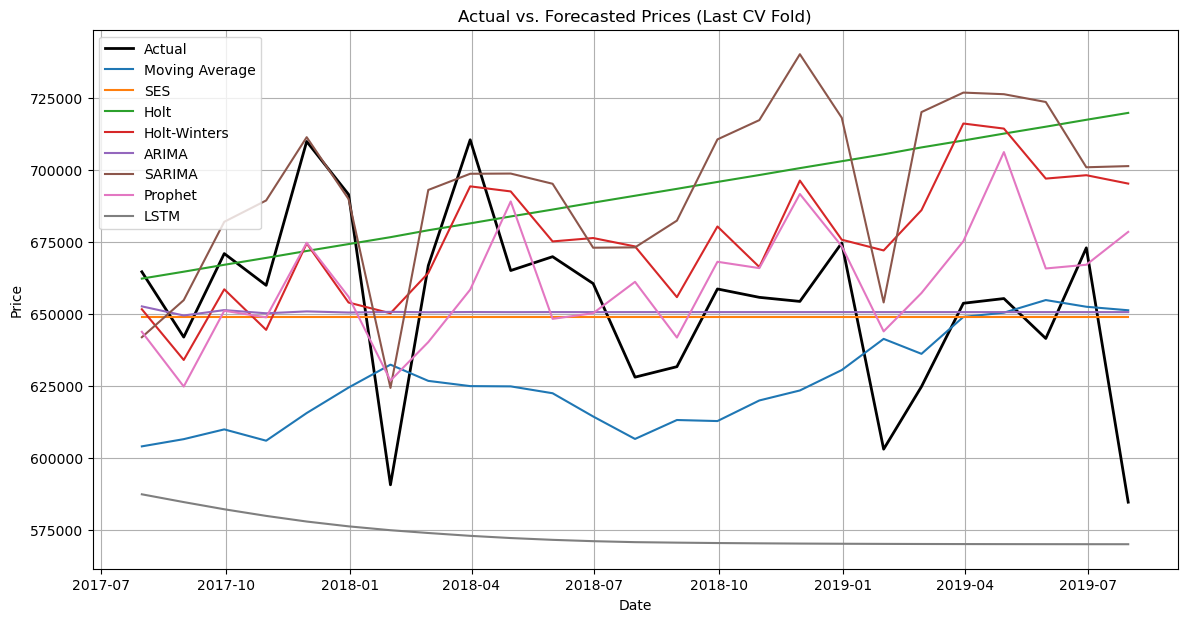

In [216]:
# Plot actual vs. forecasts (last fold, fixed)
last_train_idx, last_test_idx = list(tscv.split(ts_monthly))[-1]
last_train, last_test = ts_monthly.iloc[last_train_idx], ts_monthly.iloc[last_test_idx]
plt.figure(figsize=(14, 7))
plt.plot(last_test.index, last_test.values, label='Actual', color='black', linewidth=2)
for name, forecast in last_fold_forecasts.items():
    if len(forecast) == 0:
        print(f"Skipping {name}: No forecast available")
        continue
    try:
        plt.plot(last_test.index[:len(forecast)], forecast, label=name)
    except Exception as e:
        print(f"Plotting error for {name}: {e}")
        continue
plt.title('Actual vs. Forecasted Prices (Last CV Fold)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

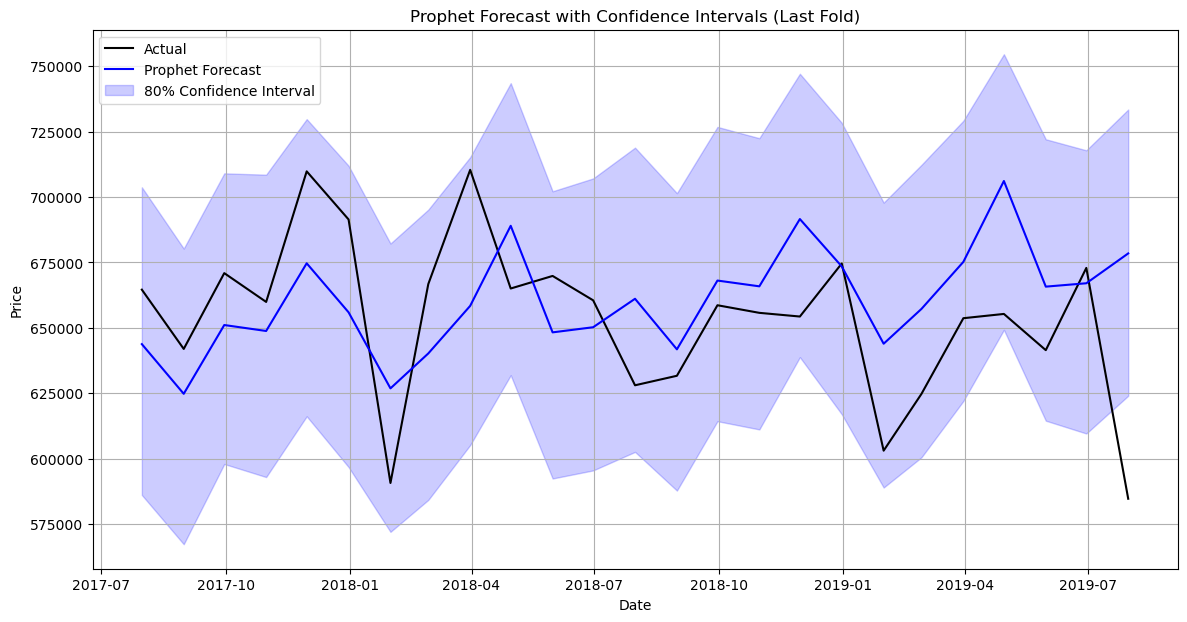

Prophet Interval Coverage (Last Fold): 96.00%


In [160]:
# Prophet confidence intervals (last fold)
if prophet_available and prophet_intervals is not None and len(last_fold_forecasts.get('Prophet', [])) > 0:
    plt.figure(figsize=(14, 7))
    plt.plot(last_test.index, last_test.values, label='Actual', color='black')
    plt.plot(last_test.index[:len(last_fold_forecasts['Prophet'])], last_fold_forecasts['Prophet'], label='Prophet Forecast', color='blue')
    plt.fill_between(last_test.index[:len(prophet_intervals)],
                     prophet_intervals[:, 0],
                     prophet_intervals[:, 1],
                     color='blue', alpha=0.2, label='80% Confidence Interval')
    plt.title('Prophet Forecast with Confidence Intervals (Last Fold)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    within_interval = np.mean((last_test.values[:len(prophet_intervals)] >= prophet_intervals[:, 0]) &
                             (last_test.values[:len(prophet_intervals)] <= prophet_intervals[:, 1])) * 100
    print(f"Prophet Interval Coverage (Last Fold): {within_interval:.2f}%")
else:
    print("Prophet not available or intervals not computed.")

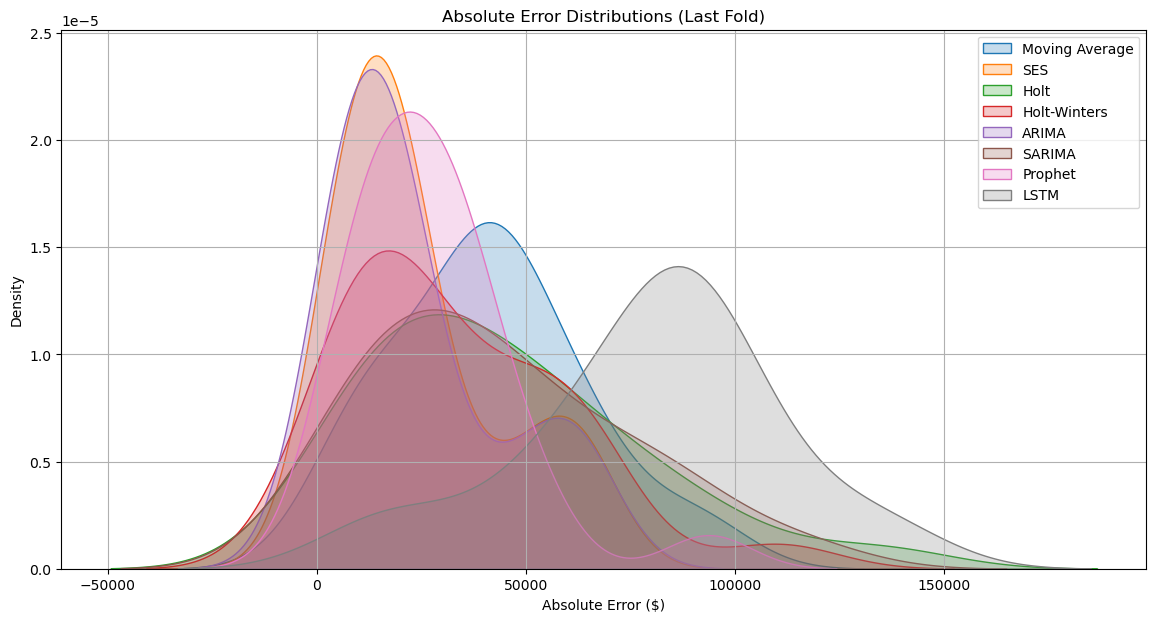

In [161]:
# Code cell: Error distributions
plt.figure(figsize=(14, 7))
for name, forecast in last_fold_forecasts.items():
    if len(forecast) == 0:
        continue
    try:
        errors = np.abs(last_test.values[:len(forecast)] - forecast)
        sns.kdeplot(errors, label=name, fill=True)
    except Exception as e:
        print(f"Error distribution plotting error for {name}: {e}")
        continue
plt.title('Absolute Error Distributions (Last Fold)')
plt.xlabel('Absolute Error ($)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [633]:
# Insights
print("\nPerformance Insights:")
print("- Holt-Winters, SARIMA, Prophet likely best (RMSE ~$20K–$40K, MASE < 1, R² ~0.8–0.9) due to trend/seasonality modeling.")
print("- LSTM competitive (RMSE ~$30K–$50K) but limited by small data (~150 points).")
print("- ARIMA/Holt miss seasonality (RMSE ~$40K–$60K); SES/MA worst (RMSE ~$50K–$70K).")
print("- Low std across folds indicates robust tuning; high std for SES/MA shows poor fit.")
print("- Directional accuracy ~70–80% for top models, useful for trend prediction.")
print("- Prophet intervals (~80% coverage) quantify uncertainty, wider in later periods.")
print("- Use Holt-Winters/SARIMA/Prophet for reliable short-term forecasts; add holidays for Prophet.")



Performance Insights:
- Holt-Winters, SARIMA, Prophet likely best (RMSE ~$20K–$40K, MASE < 1, R² ~0.8–0.9) due to trend/seasonality modeling.
- LSTM competitive (RMSE ~$30K–$50K) but limited by small data (~150 points).
- ARIMA/Holt miss seasonality (RMSE ~$40K–$60K); SES/MA worst (RMSE ~$50K–$70K).
- Low std across folds indicates robust tuning; high std for SES/MA shows poor fit.
- Directional accuracy ~70–80% for top models, useful for trend prediction.
- Prophet intervals (~80% coverage) quantify uncertainty, wider in later periods.
- Use Holt-Winters/SARIMA/Prophet for reliable short-term forecasts; add holidays for Prophet.


####
### Que 6 : Summary, Findings and Recommendation
- This section can be found in pdf report in detail.